PURPOSE:

To show results, error rate, and comparison between the normal and attack scenarios.

# Results Analysis – Quantum Secure Communication

This notebook analyzes the error rates in secure and attack scenarios.

**Note:** this now reads the *actual* output files written by
`src/main.py` (in `../results/`) instead of hardcoded numbers, so the
numbers below always reflect a real run. Run `python ../src/main.py`
first if you haven't yet, or just re-run it to refresh these values.

In [1]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results')

def read_error_rate(path):
    text = Path(path).read_text()
    match = re.search(r"Error Rate \(QBER\)\s*:\s*([0-9.]+)", text)
    if not match:
        raise ValueError(f"Could not find error rate in {path}")
    return float(match.group(1))

no_attack_rate = read_error_rate(RESULTS_DIR / 'no_attack_output.txt')
attack_rate = read_error_rate(RESULTS_DIR / 'attack_output.txt')
no_attack_rate, attack_rate

(0.0, 0.3)

We compare two scenarios:
1. Normal communication (no attacker)
2. Attack scenario (eavesdropper present, intercept-resend)

The Quantum Bit Error Rate (QBER) is what `adaptive_intrusion_detection`
uses to decide whether to accept or reject the exchanged key.

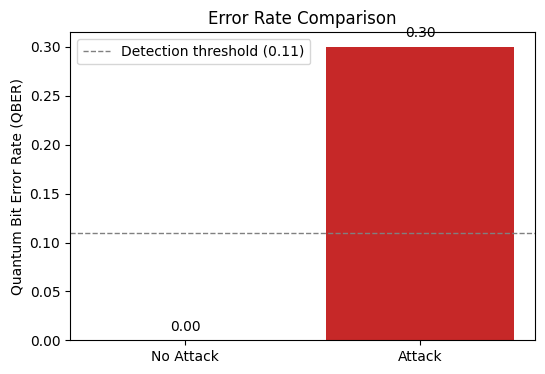

In [2]:
cases = ['No Attack', 'Attack']
error_rates = [no_attack_rate, attack_rate]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cases, error_rates, color=['#2e7d32', '#c62828'])
ax.axhline(0.11, color='gray', linestyle='--', linewidth=1, label='Detection threshold (0.11)')
ax.set_ylabel('Quantum Bit Error Rate (QBER)')
ax.set_title('Error Rate Comparison')
ax.legend()
for bar, value in zip(bars, error_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{value:.2f}', ha='center')
plt.show()

## Conclusion

The normal scenario stays well under the detection threshold, while the
intercept-resend attack pushes the QBER to roughly 25% — consistent with
BB84 theory — well above the threshold, so the key is correctly rejected.